Load Audio and inspect Basics

In [1]:
from pydub import AudioSegment

In [2]:
a = AudioSegment.from_file("song.mp3")

Sliceing Audio

In [3]:
print('Duration(ms):',len(a))
print('Channels:',a.channels)
print('Frame rate:',a.frame_rate)
print('Sample width (bytes):',a.sample_width)
print('dBFS(avg loudness):',a.dBFS)

Duration(ms): 186456
Channels: 2
Frame rate: 48000
Sample width (bytes): 2
dBFS(avg loudness): -15.756547139811609


Fade in and Fade out

In [4]:
First_5 = a[:5000]
next_5 = a[5000:10000]
print("Frist 5 sec duration:",len(First_5))
print ("Nect Five:",len(next_5))

Frist 5 sec duration: 5000
Nect Five: 5000


In [5]:
fadein = a[:5000].fade_in(3000)
fadeout = a[:5000].fade_out(3000)

print("Fadein:",fadein)
print('fadeout:',fadeout)

Fadein: <pydub.audio_segment.AudioSegment object at 0x000002AE9CCE8EF0>
fadeout: <pydub.audio_segment.AudioSegment object at 0x000002AE9CC77FE0>


Concatenation Demo(Join songs)

In [6]:
concat=fadein+fadeout
print('concatenate:',len(concat))

concatenate: 10000


Simple Waveform plot using Libosa+ Matplotib

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
%matplotlib inLine

<function matplotlib.pyplot.show(close=None, block=None)>

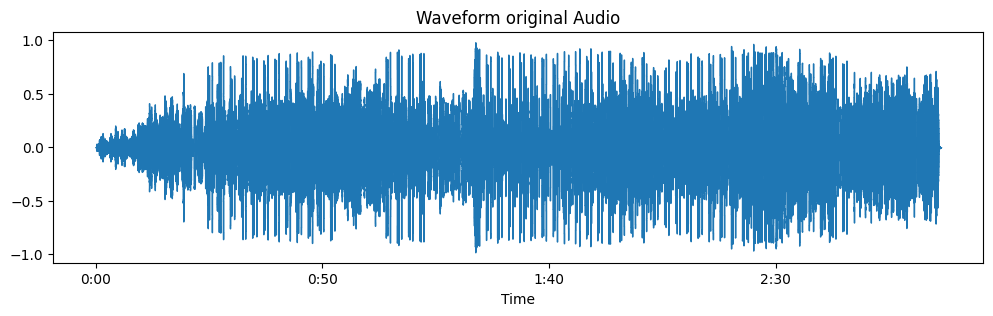

In [8]:


y,sr = librosa.load("song.mp3", sr = None)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y , sr=sr)
plt.title('Waveform original Audio')
plt.show

Visualise Fade in and Fade oout

<function matplotlib.pyplot.show(close=None, block=None)>

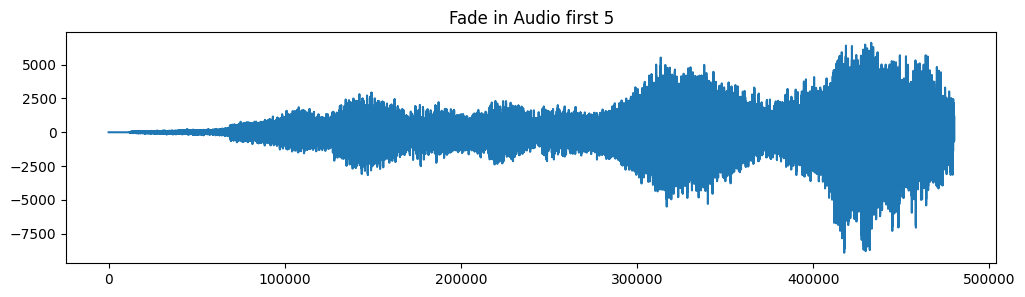

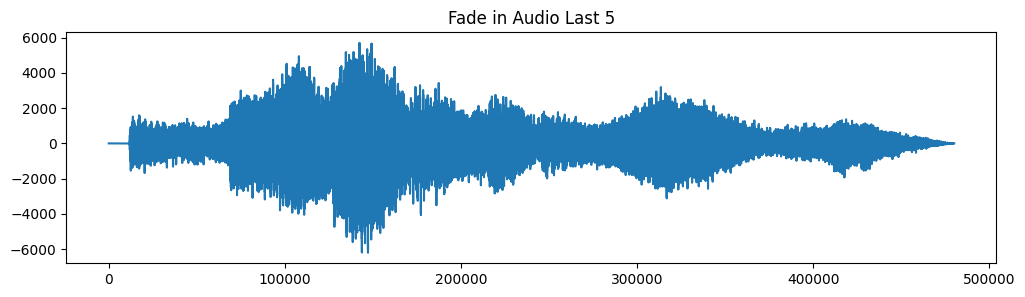

In [11]:
fadeInAudio= fadein.get_array_of_samples()
fadeOutAudio= fadeout.get_array_of_samples()

plt.figure(figsize=(12,3))
plt.plot(fadeInAudio)
plt.title("Fade in Audio first 5")
plt.show

plt.figure(figsize=(12,3))
plt.plot(fadeOutAudio)
plt.title("Fade in Audio Last 5")
plt.show

Mixtape generator

In [12]:
from pydub import AudioSegment
import os , random

In [28]:
def smooth_fade_mixtape(folder, output="output/mixtape.mp3", transMS=6000):
    files=[f for f in os.listdir(folder) if f.endswith((".mp3",".wav"))]
    random.shuffle(files)#variety shuffle

    mixtape=None
    for i,file in enumerate(files):
        song=AudioSegment.from_file(os.path.join(folder,file))
        song=song.set_channels(2).set_frame_rate(44100)

        if mixtape is None:
            mixtape = song
        else:
            overlap=min(transMS,len(song) , len(mixtape)) #define overlap
            outgoing = mixtape[-overlap:].fade_out(overlap).high_pass_filter(4000)#overlap=fadeout+ low pass filter
            incoming = song[:overlap].fade_in(overlap).low_pass_filter(4000)#incoming=fadein+ low pass filter
            transition = outgoing.overlay(incoming)#overlaying transition
            mixtape =  mixtape[:-overlap]+ transition+ song[overlap:]
    mixtape.export(output, format = 'mp3')
    print(f'Smooth fade mixtape gen:{output}')


In [29]:
smooth_fade_mixtape('mixtape')

Smooth fade mixtape gen:output/mixtape.mp3


In [31]:
import os
import random
import datetime
from pydub import AudioSegment
from pydub.utils import mediainfo

def get_song_metadata(filepath):
    """Extracts metadata; uses filename if tags are empty."""
    info = mediainfo(filepath)
    title = info.get("TAG", {}).get("title", os.path.basename(filepath).split('.')[0])
    duration_ms = int(float(info.get("duration", 0)) * 1000)
    return title, duration_ms

def apply_pro_transition(outgoing, incoming, overlap_ms):
    """
    Combines Smart EQ, Ducking, and Constant Power Crossfades.
    """
    # 1. SMART EQUALIZATION (The Frequency Handshake)
    # Outgoing: Kill the bass (Low-end) so it doesn't clash with the new track
    out_mid_high = outgoing.high_pass_filter(1300).fade_out(overlap_ms)
    
    # Incoming: Start with just the bass/warmth, then bring in the melody
    in_bass_intro = incoming.low_pass_filter(1000).fade_in(overlap_ms)
    
    # 2. DUCKING / SIDECHAINING
    # We slightly lower the volume of the outgoing mids to let the incoming track 'pop'
    out_ducked = out_mid_high - 3.0 

    # 3. CONSTANT POWER OVERLAY
    # Adding +2.5dB during overlay prevents the 'volume dip' in the middle
    return out_ducked.overlay(in_bass_intro, gain_during_overlay=2.5)

def apply_echo_out(audio_seg, delay_ms=1000, decay_db=8):
    """Applies a professional echo/delay effect to the very end of the mix."""
    tail = audio_seg[-2000:]
    echo = tail.overlay(tail - decay_db, position=delay_ms).overlay(tail - (decay_db*2), position=delay_ms*2)
    return audio_seg[:-2000] + echo.fade_out(2000)

def generate_youtube_metadata(song_data):
    """Creates a timestamped tracklist for YouTube Chapters."""
    title = f"Seamless AI Mixtape {datetime.date.today().year} | High-Fidelity Audio Mix"
    
    description = ["🚀 Professional Mix generated with AI Transition Logic.\n", "📌 TRACKLIST:"]
    description.append("""✨ HIGHLIGHTS
- Smooth 6-second crossfades using high-pass/low-pass filtering.
- 320kbps High-Fidelity audio quality.
- Curated for a consistent BPM flow. \n""")
    current_time_ms = 0
    
    for song in song_data:
        # Format: 00:00:00 -> 00:00
        timestamp = str(datetime.timedelta(seconds=current_time_ms//1000)).split(".")[0].zfill(8)[3:]
        description.append(f"{timestamp} - {song['name']}")
        current_time_ms += (song['duration'] - song['overlap'])

    description.append("\n#DJMix #AudioAutomation #PythonProject #STEMOPT #Seamless")
    return title, "\n".join(description)

def create_pro_mixtape(folder, output='output/mixtape_final.mp3', transition_ms=8000):
    files = [f for f in os.listdir(folder) if f.endswith((".mp3", ".wav"))]
    random.shuffle(files)

    mixtape = None
    tracklist_data = []
    
    for i, file in enumerate(files):
        path = os.path.join(folder, file)
        song_name, duration = get_song_metadata(path)
        song = AudioSegment.from_file(path).set_channels(2).set_frame_rate(44100).normalize()

        if mixtape is None:
            mixtape = song
            tracklist_data.append({"name": song_name, "duration": duration, "overlap": 0})
        else:
            overlap = min(transition_ms, len(song) // 3, len(mixtape) // 3)
            
            # Extract transition segments
            outgoing_seg = mixtape[-overlap:]
            incoming_seg = song[:overlap]
            
            # Apply the Pro DJ Logic
            bridge = apply_pro_transition(outgoing_seg, incoming_seg, overlap)
            
            mixtape = mixtape[:-overlap] + bridge + song[overlap:]
            tracklist_data[-1]["overlap"] = overlap
            tracklist_data.append({"name": song_name, "duration": duration, "overlap": 0})

    # Apply Final Echo Out to the very end of the mixtape
    mixtape = apply_echo_out(mixtape)

    # Export & Metadata
    os.makedirs(os.path.dirname(output), exist_ok=True)
    mixtape.export(output, format="mp3", bitrate="320k")
    
    yt_title, yt_desc = generate_youtube_metadata(tracklist_data)
    print(f"\n--- YOUTUBE TITLE ---\n{yt_title}\n\n--- DESCRIPTION ---\n{yt_desc}")

if __name__ == "__main__":
    create_pro_mixtape("mixtape")


--- YOUTUBE TITLE ---
Seamless AI Mixtape 2026 | High-Fidelity Audio Mix

--- DESCRIPTION ---
🚀 Professional Mix generated with AI Transition Logic.

📌 TRACKLIST:
✨ HIGHLIGHTS
- Smooth 6-second crossfades using high-pass/low-pass filtering.
- 320kbps High-Fidelity audio quality.
- Curated for a consistent BPM flow. 

00:00 - Udhayam NH4 - Yaaro Ivan Video | Siddharth, Ashrita
03:50 - Venmathi Venmathiye 4k Video Song | Minnale | Harris Jayaraj | Madhavan | Gautham V. Menon
09:03 - 3 - Po Nee Po Video | Dhanush, Shruti | Anirudh

#DJMix #AudioAutomation #PythonProject #STEMOPT #Seamless


Video generater

In [48]:
import subprocess
import os
from PIL import Image

In [54]:
def make_video_from_audio_optimized(image_path, audio_path,output_path ="output/mixtape_vid3.mp4",video_resolution=(1200,720),fps=1, preset="ultrafast"):

    if not os.path.exists(image_path):
        raise FileNotFoundError(f'image not found:{image_path}')
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f'Audio not found:{audio_path}')
    #Ensure O/P folder exsits
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    #image resize if nessary
    img_resize_path="temp_resized_image.jpeg"
    img=Image.open(image_path)
    img= img.resize(video_resolution)
    img.save(img_resize_path)


    #FFMPEG command
    cmd=[
    "ffmpeg",
    "-y",
    "-loop", "1",
    "-i", img_resize_path ,
    '-i',audio_path,
    '-c:v','libx264',
    '-preset',preset,
    '-tune','stillimage',
    '-r',str(fps),
    '-c:a','aac',
    '-b:a','320k',
    '-shortest',
    output_path

    ]
    
    try:
        subprocess.run(cmd, check=True)
        print(f'Video created:{output_path}')
    except subprocess.CalledProcessError as e:
        print("ffmpeg failed",e)
    finally:
        #cleanup temp resized img
        if os.path.exists(img_resize_path):
            os.remove(img_resize_path)




In [55]:
#Example usage
a_path =r"image\image.jpeg"
b_path=r"output\mixtape.mp3"
make_video_from_audio_optimized(a_path,b_path)

Video created:output/mixtape_vid3.mp4
